<a href="https://colab.research.google.com/github/rickiepark/deep-learning-with-python-3rd/blob/main/chapter16_text-generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

이 노트북은 <[케라스 창시자에게 배우는 딥러닝 (개정 3판)](https://tensorflow.blog/kerasdl3/)>(길벗, 2026)의 예제 코드를 담고 있습니다.

In [1]:
!pip install keras keras-hub --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 81.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.31.0 which is incompatible.


In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [3]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"이 셀은 {required} 백엔드가 필요합니다. 실행을 위해 노트북 서두에서 KERAS_BACKEND를 "
            f"\"{required}\"로 바꾸고 런타임을 재식한 다음 노트북을 다시 실행하세요."
        )

In [4]:
import keras, keras_hub

print(keras.__version__)
print(keras_hub.__version__)

3.15.1
0.31.0


## 텍스트 생성

### 시퀀스 생성의 간략한 역사

### 미니 GPT 훈련하기

In [5]:
import os

# JAX와 텐서플로 백엔드에서 GPU 메모리 비우기
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "1.00"

In [6]:
import keras
import pathlib

extract_dir = keras.utils.get_file(
    fname="mini-c4",
    origin=(
        "https://hf.co/datasets/mattdangerw/mini-c4/resolve/main/mini-c4.zip"
    ),
    extract=True,
)
extract_dir = pathlib.Path(extract_dir) / "mini-c4"

1505728294/1505728294 ━━━━━━━━━━━━━━━━━━━━ 22s 0us/step


In [7]:
with open(extract_dir / "shard0.txt", "r") as f:
    print(f.readline().replace("\\n", "\n")[:100])

Beginners BBQ Class Taking Place in Missoula!
Do you want to get better at making delicious BBQ? You


In [8]:
import keras_hub
import numpy as np

vocabulary_file = keras.utils.get_file(
    origin="https://hf.co/mattdangerw/spiece/resolve/main/vocabulary.proto",
)
tokenizer = keras_hub.tokenizers.SentencePieceTokenizer(vocabulary_file)

499723/499723 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
tokenizer.tokenize("The quick brown fox.")

[450, 4996, 17354, 1701, 29916, 29889]

In [10]:
tokenizer.detokenize([450, 4996, 17354, 1701, 29916, 29889])

'The quick brown fox.'

In [11]:
import tensorflow as tf

batch_size = 64
sequence_length = 256
suffix = np.array([tokenizer.token_to_id("<|endoftext|>")])

def read_file(filename):
    ds = tf.data.TextLineDataset(filename)
    ds = ds.map(lambda x: tf.strings.regex_replace(x, r"\\n", "\n"))
    ds = ds.map(tokenizer, num_parallel_calls=8)
    return ds.map(lambda x: tf.concat([x, suffix], -1))

files = [str(file) for file in extract_dir.glob("*.txt")]
ds = tf.data.Dataset.from_tensor_slices(files)
ds = ds.interleave(read_file, cycle_length=32, num_parallel_calls=32)
ds = ds.rebatch(sequence_length + 1, drop_remainder=True)
ds = ds.map(lambda x: (x[:-1], x[1:]))
ds = ds.batch(batch_size).prefetch(8)

In [12]:
num_batches = 58746
num_val_batches = 500
num_train_batches = num_batches - num_val_batches
val_ds = ds.take(num_val_batches).repeat()
train_ds = ds.skip(num_val_batches).repeat()

#### 모델 만들기

In [13]:
from keras import layers

class TransformerDecoder(keras.Layer):
    def __init__(self, hidden_dim, intermediate_dim, num_heads):
        super().__init__()
        key_dim = hidden_dim // num_heads
        self.self_attention = layers.MultiHeadAttention(
            num_heads, key_dim, dropout=0.1
        )
        self.self_attention_layernorm = layers.LayerNormalization()
        self.feed_forward_1 = layers.Dense(intermediate_dim, activation="relu")
        self.feed_forward_2 = layers.Dense(hidden_dim)
        self.feed_forward_layernorm = layers.LayerNormalization()
        self.dropout = layers.Dropout(0.1)

    def call(self, inputs):
        residual = x = inputs
        x = self.self_attention(query=x, key=x, value=x, use_causal_mask=True)
        x = self.dropout(x)
        x = x + residual
        x = self.self_attention_layernorm(x)
        residual = x
        x = self.feed_forward_1(x)
        x = self.feed_forward_2(x)
        x = self.dropout(x)
        x = x + residual
        x = self.feed_forward_layernorm(x)
        return x

In [14]:
from keras import ops

class PositionalEmbedding(keras.Layer):
    def __init__(self, sequence_length, input_dim, output_dim):
        super().__init__()
        self.token_embeddings = layers.Embedding(input_dim, output_dim)
        self.position_embeddings = layers.Embedding(sequence_length, output_dim)

    def call(self, inputs, reverse=False):
        if reverse:
            token_embeddings = self.token_embeddings.embeddings
            return ops.matmul(inputs, ops.transpose(token_embeddings))
        positions = ops.cumsum(ops.ones_like(inputs), axis=-1) - 1
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions

In [15]:
keras.config.set_dtype_policy("mixed_float16")

vocab_size = tokenizer.vocabulary_size()
hidden_dim = 512
intermediate_dim = 2056
num_heads = 8
num_layers = 8

inputs = keras.Input(shape=(None,), dtype="int32", name="inputs")
embedding = PositionalEmbedding(sequence_length, vocab_size, hidden_dim)
x = embedding(inputs)
x = layers.LayerNormalization()(x)
for i in range(num_layers):
    x = TransformerDecoder(hidden_dim, intermediate_dim, num_heads)(x)
outputs = embedding(x, reverse=True)
mini_gpt = keras.Model(inputs, outputs)

#### 모델 사전 훈련하기

In [16]:
class WarmupSchedule(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self):
        self.rate = 2e-4
        self.warmup_steps = 1_000.0

    def __call__(self, step):
        step = ops.cast(step, dtype="float32")
        scale = ops.minimum(step / self.warmup_steps, 1.0)
        return self.rate * scale

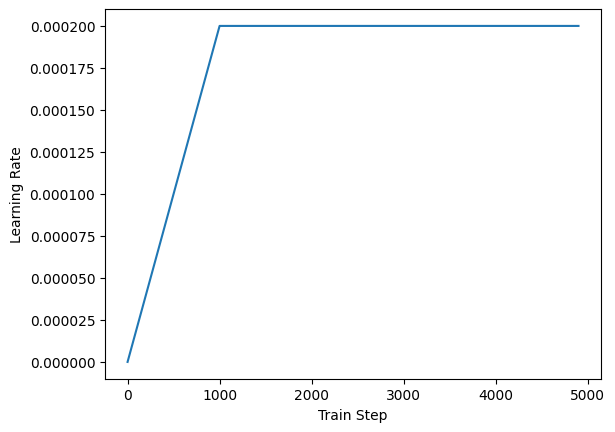

In [17]:
import matplotlib.pyplot as plt

schedule = WarmupSchedule()
x = range(0, 5_000, 100)
y = [ops.convert_to_numpy(schedule(step)) for step in x]
plt.plot(x, y)
plt.xlabel("Train Step")
plt.ylabel("Learning Rate")
plt.show()

In [18]:
# ⚠️노트⚠️: 코랩 프로 GPU를 권장합니다.
# 다음 fit 호출은 무료 GPU에서 몇 시간이 걸립니다.
# steps_per_epoch를 줄여서 훈련이 덜 된 모델을 만들어 사용할 수 있습니다.

In [19]:
num_epochs = 8
steps_per_epoch = num_train_batches // num_epochs
validation_steps = num_val_batches

mini_gpt.compile(
    optimizer=keras.optimizers.Adam(schedule),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
mini_gpt.fit(
    train_ds,
    validation_data=val_ds,
    epochs=num_epochs,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 461s 57ms/step - accuracy: 0.2060 - loss: 5.3983 - val_accuracy: 0.2804 - val_loss: 4.4801
Epoch 2/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 401s 55ms/step - accuracy: 0.2920 - loss: 4.3446 - val_accuracy: 0.3163 - val_loss: 4.1050
Epoch 3/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 402s 55ms/step - accuracy: 0.3150 - loss: 4.1047 - val_accuracy: 0.3300 - val_loss: 3.9586
Epoch 4/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 403s 55ms/step - accuracy: 0.3261 - loss: 3.9859 - val_accuracy: 0.3391 - val_loss: 3.8659
Epoch 5/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 404s 55ms/step - accuracy: 0.3336 - loss: 3.9077 - val_accuracy: 0.3451 - val_loss: 3.8055
Epoch 6/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 402s 55ms/step - accuracy: 0.3390 - loss: 3.8512 - val_accuracy: 0.3508 - val_loss: 3.7429
Epoch 7/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 400s 55ms/step - accuracy: 0.3436 - loss: 3.8071 - val_accuracy: 0.3553 - val_loss: 3.7055
Epoch 8/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 400s 55ms/step - accuracy: 0.3461 -

#### 생성 디코딩

In [22]:
def generate(prompt, max_length=64):
    tokens = list(ops.convert_to_numpy(tokenizer(prompt)))
    prompt_length = len(tokens)
    for _ in range(max_length - prompt_length):
        prediction = mini_gpt(ops.convert_to_numpy([tokens]))
        prediction = ops.convert_to_numpy(prediction[0, -1])
        tokens.append(np.argmax(prediction).item())
    return tokenizer.detokenize(np.array(tokens))

In [26]:
prompt = "A piece of advice"
generate(prompt)

'A piece of advice from a professional who is a professional and a professional.\nThe first thing you need to do is to make sure that you are not only a professional, but also a professional who is a professional.\nYou should be able to make sure that you are not only a professional, but also a professional'

In [27]:
def compiled_generate(prompt, max_length=64):
    tokens = list(ops.convert_to_numpy(tokenizer(prompt)))
    prompt_length = len(tokens)
    tokens = tokens + [0] * (max_length - prompt_length)
    for i in range(prompt_length, max_length):
        prediction = mini_gpt.predict(np.array([tokens]), verbose=0)
        prediction = prediction[0, i - 1]
        tokens[i] = np.argmax(prediction).item()
    return tokenizer.detokenize(np.array(tokens))

In [28]:
import timeit
tries = 10
timeit.timeit(lambda: compiled_generate(prompt), number=tries) / tries

0.8933022270000037

#### 샘플링 전략

In [29]:
def compiled_generate(prompt, sample_fn, max_length=64):
    tokens = list(ops.convert_to_numpy(tokenizer(prompt)))
    prompt_length = len(tokens)
    tokens = tokens + [0] * (max_length - prompt_length)
    for i in range(prompt_length, max_length):
        prediction = mini_gpt.predict(np.array([tokens]), verbose=0)
        prediction = prediction[0, i - 1]
        next_token = ops.convert_to_numpy(sample_fn(prediction))
        tokens[i] = np.array(next_token).item()
    return tokenizer.detokenize(np.array(tokens))

In [30]:
def greedy_search(preds):
    return ops.argmax(preds)

compiled_generate(prompt, greedy_search)

'A piece of advice from a professional who is a professional and a professional.\nThe first thing you need to do is to make sure that you are not only a professional, but also a professional who is a professional.\nYou should be able to make sure that you are not only a professional, but also a professional'

In [31]:
def random_sample(preds, temperature=1.0):
    preds = preds / temperature
    return keras.random.categorical(preds[None, :], num_samples=1)[0]

In [32]:
compiled_generate(prompt, random_sample)

'A piece of advice, you are being charged with and then your soccer games have been dealt with.\nTIP! All the actions and rituals available to you will be handled in accordance with the safety guidelines of the school courts. The teacher will ask you to adopt a proper procedure by rem'

In [33]:
from functools import partial
compiled_generate(prompt, partial(random_sample, temperature=2.0))

'A piece of advice took part even tbmed the box many mrapeinged letters speak over racks using open hairy stearers before bringing music lyrics they gather to add sounds to remeach schools (type). Burch’own Voices follows eight SIB F record items with him whose production'

In [34]:
compiled_generate(prompt, partial(random_sample, temperature=0.8))

'A piece of advice for this one. The new book will be published in 24 languages. I have a chapter where I have to read each book. ⁇  Thanks for this post. Thank you.\nI am currently trying to use a book for the UC. I will use it again next week.\n'

In [35]:
compiled_generate(prompt, partial(random_sample, temperature=0.2))

'A piece of advice from a professional who has been working with the company for over 20 years.\nThe company has been working with the company since 2015.\nThe company has been working with the company since 2015. The company has been working with the company since 2'

In [36]:
def top_k(preds, k=5, temperature=1.0):
    preds = preds / temperature
    top_preds, top_indices = ops.top_k(preds, k=k, sorted=False)
    choice = keras.random.categorical(top_preds[None, :], num_samples=1)[0]
    return ops.take_along_axis(top_indices, choice, axis=-1)

In [37]:
compiled_generate(prompt, partial(top_k, k=5))

'A piece of advice from a professional, and the expertise you’ve been looking for.\nA great guide to how you can use a professional to help you achieve your goals.\nA guide to how you can use a professional to help you achieve your goals!\nA guide to how you can use a professional'

In [38]:
compiled_generate(prompt, partial(top_k, k=20))

'A piece of advice for your children to take the time to think carefully. The goal of these tips is to help people to make a positive difference in their children’s life. To keep things simple, make sure your children are on the right page for each day. This way you can improve your children’s life'

In [39]:
compiled_generate(prompt, partial(top_k, k=5, temperature=0.5))

'A piece of advice to the reader of the 1960s.\nThe first book was published in 1962 and is available in 1962. It was published in 1963 and is available in 1965.\nThe first book was published in'

### 사전 훈련된 LLM 사용하기

#### 젬마 모델로 텍스트 생성하기

In [40]:
import kagglehub

kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [42]:
gemma_lm = keras_hub.models.CausalLM.from_preset(
    "gemma3_1b",
    dtype="float32",
)

100%|██████████| 966/966 [00:00<00:00, 2.37MB/s]


100%|██████████| 3.23k/3.23k [00:00<00:00, 6.04MB/s]
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:431: UserWarning: `build()` was called on layer 'gemma3_causal_lm', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


100%|██████████| 4.47M/4.47M [00:00<00:00, 15.6MB/s]


100%|██████████| 1.86G/1.86G [00:24<00:00, 80.3MB/s]


In [43]:
gemma_lm.summary(line_length=80)

Preprocessor: "gemma3_causal_lm_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                 ┃                        Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ gemma3_tokenizer (Gemma3Tokenizer)           │           Vocab size: 262,144 │
└──────────────────────────────────────────────┴───────────────────────────────┘

Model: "gemma3_causal_lm"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask          │ (None, None)      │           0 │ -                  │
│ (InputLayer)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ token_ids             │ (None, None)      │           0 │ -                  │
│ (InputLayer)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ gemma3_backbone       │ (None, None,      │ 999,885,952 │ padding_mask[0][0… │
│ (Gemma3Backbone)      │ 1152)             │             │ token_ids[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ token_embedding       │ (None, None,      │ 301,989,888 │ gemma3_backbone[0… │
│ (ReversibleEmbedding) │ 262144)           │             │                    │
└───────────────────────┴───────────────────┴─────────────┴────────────────────┘

 Total params: 999,885,952 (3.72 GB)

 Trainable params: 999,885,952 (3.72 GB)

 Non-trainable params: 0 (0.00 B)

In [44]:
gemma_lm.compile(sampler="greedy")
gemma_lm.generate("A piece of advice", max_length=40)

'A piece of advice from a former student of mine:\n\n<blockquote>“I’m not sure if you’ve heard of it, but I’ve been told that the best way to learn'

In [45]:
gemma_lm.generate("How can I make brownies?", max_length=40)

"How can I make brownies?\n\n[User 0001]\n\nI'm trying to make brownies for my son's birthday party. I've never made brownies before."

In [46]:
gemma_lm.generate(
    "The following brownie recipe is easy to make in just a few "
    "steps.\n\nYou can start by",
    max_length=40,
)

'The following brownie recipe is easy to make in just a few steps.\n\nYou can start by melting the butter and sugar in a saucepan over medium heat.\n\nThen add the eggs and vanilla extract'

In [47]:
gemma_lm.generate(
    "Tell me about the 542nd president of the United States.",
    max_length=40,
)

'Tell me about the 542nd president of the United States.\n\nThe 542nd president of the United States was James A. Garfield.\n\nThe 542'

#### 지시 미세 튜닝

In [48]:
import json

PROMPT_TEMPLATE = """"[instruction]\n{}[end]\n[response]\n"""
RESPONSE_TEMPLATE = """{}[end]"""

dataset_path = keras.utils.get_file(
    origin=(
        "https://hf.co/datasets/databricks/databricks-dolly-15k/"
        "resolve/main/databricks-dolly-15k.jsonl"
    ),
)
data = {"prompts": [], "responses": []}
with open(dataset_path) as file:
    for line in file:
        features = json.loads(line)
        if features["context"]:
            continue
        data["prompts"].append(PROMPT_TEMPLATE.format(features["instruction"]))
        data["responses"].append(RESPONSE_TEMPLATE.format(features["response"]))

13085339/13085339 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [49]:
data["prompts"][0]

'"[instruction]\nWhich is a species of fish? Tope or Rope[end]\n[response]\n'

In [50]:
data["responses"][0]

'Tope[end]'

In [51]:
ds = tf.data.Dataset.from_tensor_slices(data).shuffle(2000).batch(2)
val_ds = ds.take(100)
train_ds = ds.skip(100)

In [52]:
preprocessor = gemma_lm.preprocessor
preprocessor.sequence_length = 512
batch = next(iter(train_ds))
x, y, sample_weight = preprocessor(batch)
x["token_ids"].shape

(2, 512)

In [53]:
x["padding_mask"].shape

(2, 512)

In [54]:
y.shape

(2, 512)

In [55]:
sample_weight.shape

(2, 512)

In [56]:
x["token_ids"][0, :5], y[0, :5]

(Array([     2,  77074,  22768, 236842,    107], dtype=int32),
 Array([ 77074,  22768, 236842,    107,   3689], dtype=int32))

#### LoRA

In [57]:
gemma_lm.backbone.enable_lora(rank=8)

In [58]:
gemma_lm.summary(line_length=80)

Preprocessor: "gemma3_causal_lm_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                 ┃                        Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ gemma3_tokenizer (Gemma3Tokenizer)           │           Vocab size: 262,144 │
└──────────────────────────────────────────────┴───────────────────────────────┘

Model: "gemma3_causal_lm"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask          │ (None, None)      │           0 │ -                  │
│ (InputLayer)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ token_ids             │ (None, None)      │           0 │ -                  │
│ (InputLayer)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ gemma3_backbone       │ (None, None,      │ 1,001,190,… │ padding_mask[0][0… │
│ (Gemma3Backbone)      │ 1152)             │             │ token_ids[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ token_embedding       │ (None, None,      │ 301,989,888 │ gemma3_backbone[0… │
│ (ReversibleEmbedding) │ 262144)           │             │                    │
└───────────────────────┴───────────────────┴─────────────┴────────────────────┘

 Total params: 1,001,190,528 (3.73 GB)

 Trainable params: 1,304,576 (4.98 MB)

 Non-trainable params: 999,885,952 (3.72 GB)

In [59]:
gemma_lm.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(5e-5),
    weighted_metrics=[keras.metrics.SparseCategoricalAccuracy()],
)
gemma_lm.fit(train_ds, validation_data=val_ds, epochs=1)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


5172/5172 ━━━━━━━━━━━━━━━━━━━━ 365s 60ms/step - loss: 0.3265 - sparse_categorical_accuracy: 0.5425 - val_loss: 0.3183 - val_sparse_categorical_accuracy: 0.5599


In [60]:
gemma_lm.generate(
    "[instruction]\nHow can I make brownies?[end]\n"
    "[response]\n",
    max_length=512,
)

'[instruction]\nHow can I make brownies?[end]\n[response]\nBrownies are a classic American dessert. They are made with a base of flour, sugar, and butter, and then topped with chocolate or other sweet toppings. They are often served with a scoop of vanilla ice cream or whipped cream. Brownies can be made with a variety of ingredients, including chocolate chips, nuts, and spices. They are a delicious and versatile dessert that is enjoyed by people of all ages.[end]'

In [61]:
gemma_lm.generate(
    "[instruction]\nWhat is a proper noun?[end]\n"
    "[response]\n",
    max_length=512,
)

'[instruction]\nWhat is a proper noun?[end]\n[response]\nA proper noun is a word that refers to a specific person, place, or thing. Proper nouns are usually capitalized. For example, "John Smith" is a proper noun. "The White House" is also a proper noun. "The United States" is also a proper noun. "The United States of America" is not a proper noun.[end]'

In [62]:
gemma_lm.generate(
    "[instruction]\nWho is the 542nd president of the United States?[end]\n"
    "[response]\n",
    max_length=512,
)

'[instruction]\nWho is the 542nd president of the United States?[end]\n[response]\nThe 542nd president of the United States was James A. Garfield. Garfield was elected to the presidency in 1880, but was assassinated in 1881. He was succeeded by Chester A. Arthur.[end]'

### LLM 심화 주제

#### RLHF

##### RLHF로 훈련된 챗봇 사용하기

In [63]:
# ⚠️노트⚠️: 40억 파라미터 모델이므로 무료 코랩 GPU를 사용한다면 메모리를 확보하기 위해
# 런타임을 다시 시작하고 이 지점부터 노트북을 다시 실행하세요.
import os

os.environ["KERAS_BACKEND"] = "jax"
# Free up more GPU memory on the Jax and TensorFlow backends.
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "1.00"

import keras
import keras_hub
import kagglehub
import numpy as np

kagglehub.login()

In [64]:
gemma_lm = keras_hub.models.CausalLM.from_preset(
    "gemma3_instruct_4b",
    dtype="bfloat16",
)

100%|██████████| 1.84k/1.84k [00:00<00:00, 3.77MB/s]


100%|██████████| 5.55k/5.55k [00:00<00:00, 8.04MB/s]


100%|██████████| 4.47M/4.47M [00:00<00:00, 32.8MB/s]


100%|██████████| 8.79G/8.79G [02:21<00:00, 66.7MB/s]


In [65]:
PROMPT_TEMPLATE = """<start_of_turn>user
{}<end_of_turn>
<start_of_turn>model
"""

In [66]:
prompt = "Why can't you assign values in Jax tensors? Be brief!"
gemma_lm.generate(PROMPT_TEMPLATE.format(prompt), max_length=512)

"<start_of_turn>user\nWhy can't you assign values in Jax tensors? Be brief!<end_of_turn>\n<start_of_turn>model\nJax tensors are immutable. You can't directly change their values; instead, you create new tensors with the desired values through operations. This is core to Jax's performance optimization and automatic differentiation.<end_of_turn>"

In [67]:
prompt = "Who is the 542nd president of the United States?"
gemma_lm.generate(PROMPT_TEMPLATE.format(prompt), max_length=512)

"<start_of_turn>user\nWho is the 542nd president of the United States?<end_of_turn>\n<start_of_turn>model\nThis is a trick question! As of today, November 2, 2023, the United States has only had 46 presidents. There hasn't been a 542nd president yet. 😊 \n\nYou're playing with a very large number!<end_of_turn>"

#### 멀티모달 LLM

8495035/8495035 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


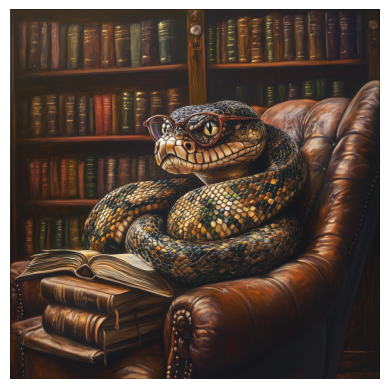

In [68]:
import matplotlib.pyplot as plt

image_url = (
    "https://github.com/mattdangerw/keras-nlp-scripts/"
    "blob/main/learned-python.png?raw=true"
)
image_path = keras.utils.get_file(origin=image_url)

image = np.array(keras.utils.load_img(image_path))
plt.axis("off")
plt.imshow(image)
plt.show()

In [69]:
gemma_lm.preprocessor.max_images_per_prompt = 1
gemma_lm.preprocessor.sequence_length = 512
prompt = "What is going on in this image? Be concise!<start_of_image>"
gemma_lm.generate({
    "prompts": PROMPT_TEMPLATE.format(prompt),
    "images": [image],
})

'<start_of_turn>user\nWhat is going on in this image? Be concise!\n\n<start_of_image>\n\n<end_of_turn>\n<start_of_turn>model\nA snake wearing glasses is sitting in a leather armchair, surrounded by a large bookshelf, and reading a book. It’s a whimsical, slightly surreal image.<end_of_turn>'

In [70]:
prompt = "What is the snake wearing?<start_of_image>"
gemma_lm.generate({
    "prompts": PROMPT_TEMPLATE.format(prompt),
    "images": [image],
})

'<start_of_turn>user\nWhat is the snake wearing?\n\n<start_of_image>\n\n<end_of_turn>\n<start_of_turn>model\nThe snake is wearing a pair of glasses! They are red-framed and perched on its head.<end_of_turn>'

##### 파운데이션 모델

#### 검색 증강 생성

#### "추론" 모델

In [71]:
prompt = """Judy wrote a 2-page letter to 3 friends twice a week for 3 months.
How many letters did she write?
Be brief, and add "ANSWER:" before your final answer."""

gemma_lm.compile(sampler="random")

In [72]:
gemma_lm.generate(PROMPT_TEMPLATE.format(prompt))

'<start_of_turn>user\nJudy wrote a 2-page letter to 3 friends twice a week for 3 months.\nHow many letters did she write?\nBe brief, and add "ANSWER:" before your final answer.<end_of_turn>\n<start_of_turn>model\nHere\'s how to solve the problem:\n\n* **Letters per week:** 3 friends * 2 letters/week = 6 letters/week\n* **Letters per month:** 6 letters/week * 4 weeks/month = 24 letters/month\n* **Total letters:** 24 letters/month * 3 months = 72 letters\n\nANSWER: 72<end_of_turn>'

In [73]:
gemma_lm.generate(PROMPT_TEMPLATE.format(prompt))

'<start_of_turn>user\nJudy wrote a 2-page letter to 3 friends twice a week for 3 months.\nHow many letters did she write?\nBe brief, and add "ANSWER:" before your final answer.<end_of_turn>\n<start_of_turn>model\nHere\'s how to calculate the total number of letters:\n\n*   **Letters per week:** 3 friends * 2 letters/friend/week = 6 letters/week\n*   **Letters per month:** 6 letters/week * 4 weeks/month = 24 letters/month\n*   **Letters in 3 months:** 24 letters/month * 3 months = 72 letters\n*   **Total letters:** 72 letters * 2 pages = 144 pages\n\nSince the question is about the number of letters, not the pages, we\'ll stick with the number of letters written.\n\nANSWER: 72<end_of_turn>'

### LLM은 어디로 향하고 있나요?